In [ ]:
pip install pandas matplotlib

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('/content/Chocolate Sales.csv')  # Replace with your file path

# --------------------
# STEP 1: Data Cleaning
# --------------------
def clean_data(df):
    # Clean 'Amount' column: Remove "$" and convert to float
    df['Amount'] = df['Amount'].str.replace('[\$, ]', '', regex=True).astype(float)

    # Convert 'Date' to datetime format
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

    # Check for missing values
    print("Missing values before cleaning:")
    print(df.isnull().sum())

    # Drop rows with missing critical data (Amount or Boxes Shipped)
    df = df.dropna(subset=['Amount', 'Boxes Shipped'])
    print("\nMissing values after dropping rows with missing data:")
    print(df.isnull().sum())

    # Remove duplicates
    initial_rows = df.shape[0]
    df = df.drop_duplicates()
    final_rows = df.shape[0]
    print(f"\nDuplicates removed: {initial_rows - final_rows}")

    return df

df_clean = clean_data(df)

# --------------------
# STEP 2: Data Processing
# --------------------
# Feature engineering: Add month/year and revenue per box
df_clean['Month'] = df_clean['Date'].dt.month_name()
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Revenue per Box'] = df_clean['Amount'] / df_clean['Boxes Shipped']

# --------------------
# STEP 3: Analysis
# --------------------
# Summary statistics
print("\nSummary Statistics:")
print(df_clean.describe())

# Top 5 products by total revenue
top_products = df_clean.groupby('Product')['Amount'].sum().nlargest(5)
print("\nTop 5 Products by Revenue:")
print(top_products)

# Sales by country
country_sales = df_clean.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print("\nSales by Country:")
print(country_sales)

# Monthly sales trends
monthly_sales = df_clean.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly_sales['Month_Order'] = pd.to_datetime(monthly_sales['Month'], format='%B').dt.month
monthly_sales = monthly_sales.sort_values(['Year', 'Month_Order'])

# Top salespeople
top_salespeople = df_clean.groupby('Sales Person')['Amount'].sum().nlargest(5)
print("\nTop 5 Salespeople:")
print(top_salespeople)



# Save processed data (optional)
df_clean.to_csv('Processed_Chocolate_Sales.csv', index=False)

Missing values before cleaning:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Missing values after dropping rows with missing data:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Duplicates removed: 0

Summary Statistics:
                                Date        Amount  Boxes Shipped    Year  \
count                           1094   1094.000000    1094.000000  1094.0   
mean   2022-05-03 09:04:56.160877568   5652.308044     161.797989  2022.0   
min              2022-01-03 00:00:00      7.000000       1.000000  2022.0   
25%              2022-03-02 00:00:00   2390.500000      70.000000  2022.0   
50%              2022-05-11 00:00:00   4868.500000     135.000000  2022.0   
75%              2022-07-04 00:00:00   8027.250000     228.750000  2022.0   
max              2022-08-31 00:00:00  22050.000000     709.000000  2022.0   

In [ ]:
pip install pandas matplotlib seaborn

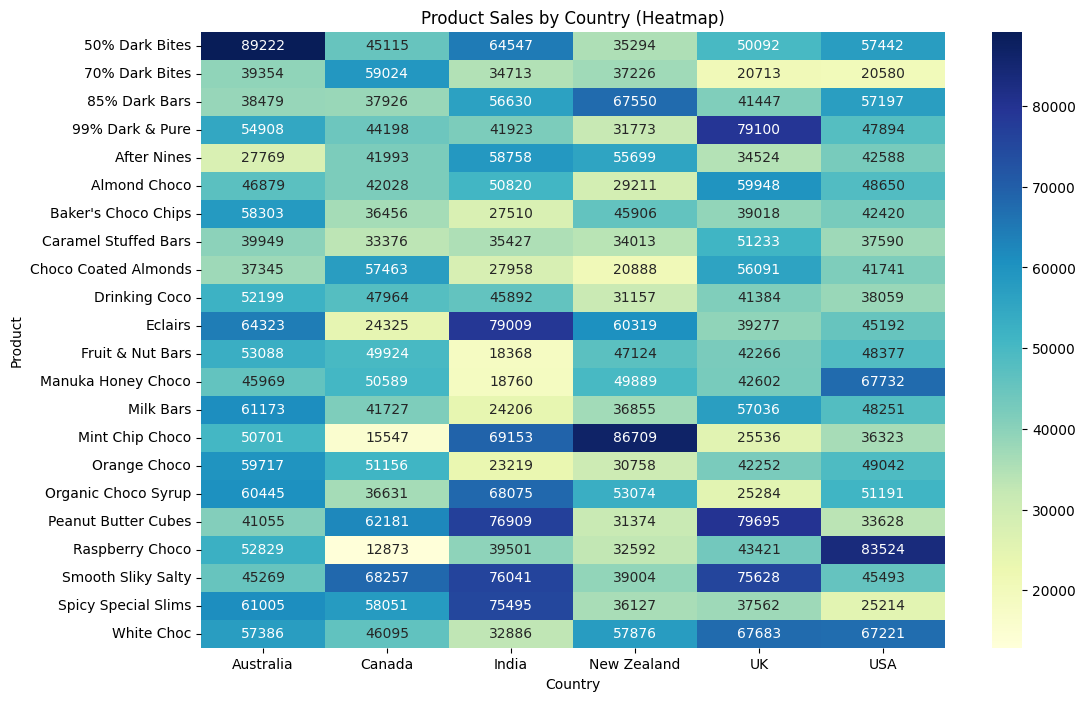

In [ ]:
# Pivot table: Product sales by country
import seaborn as sns # Import the seaborn library

product_country = df_clean.pivot_table(
    index='Product',
    columns='Country',
    values='Amount',
    aggfunc='sum',
    fill_value=0
)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(product_country, annot=True, fmt=".0f", cmap='YlGnBu') # Now sns is defined
plt.title('Product Sales by Country (Heatmap)')
plt.xlabel('Country')
plt.ylabel('Product')
plt.show()

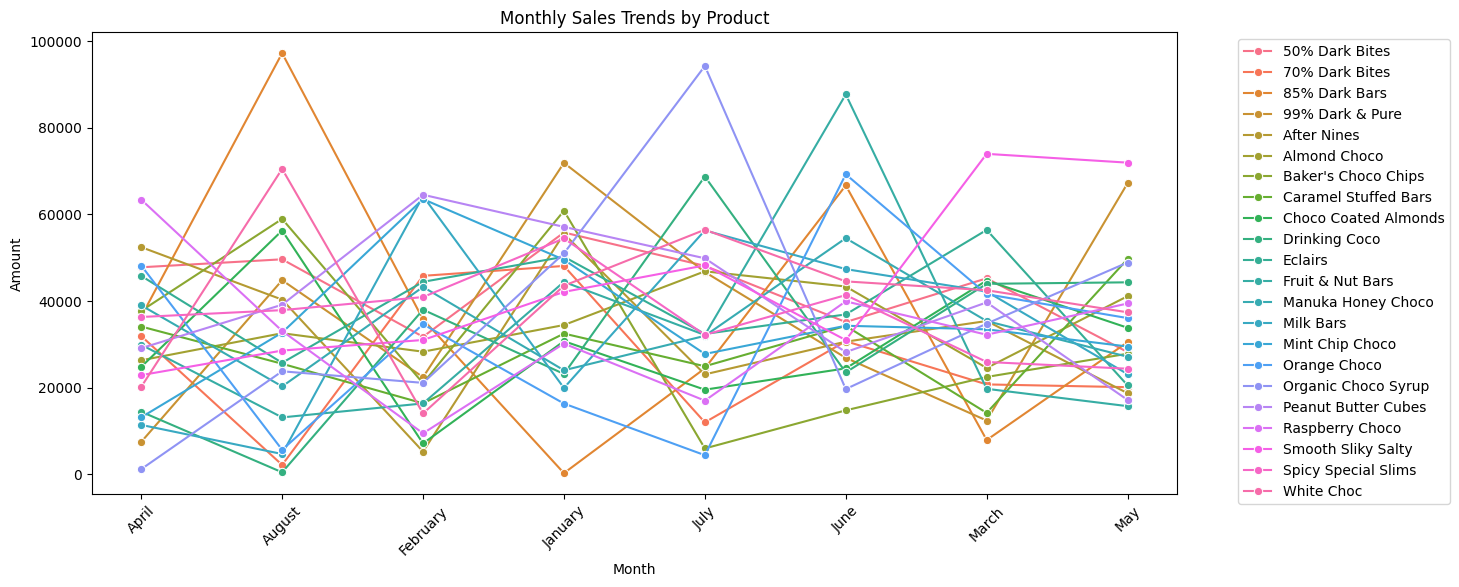

In [ ]:
# Group by month and product
monthly_product = df_clean.groupby(['Month', 'Product'])['Amount'].sum().reset_index()

# Line plot
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_product,
    x='Month',
    y='Amount',
    hue='Product',
    marker='o'
)
plt.title('Monthly Sales Trends by Product')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

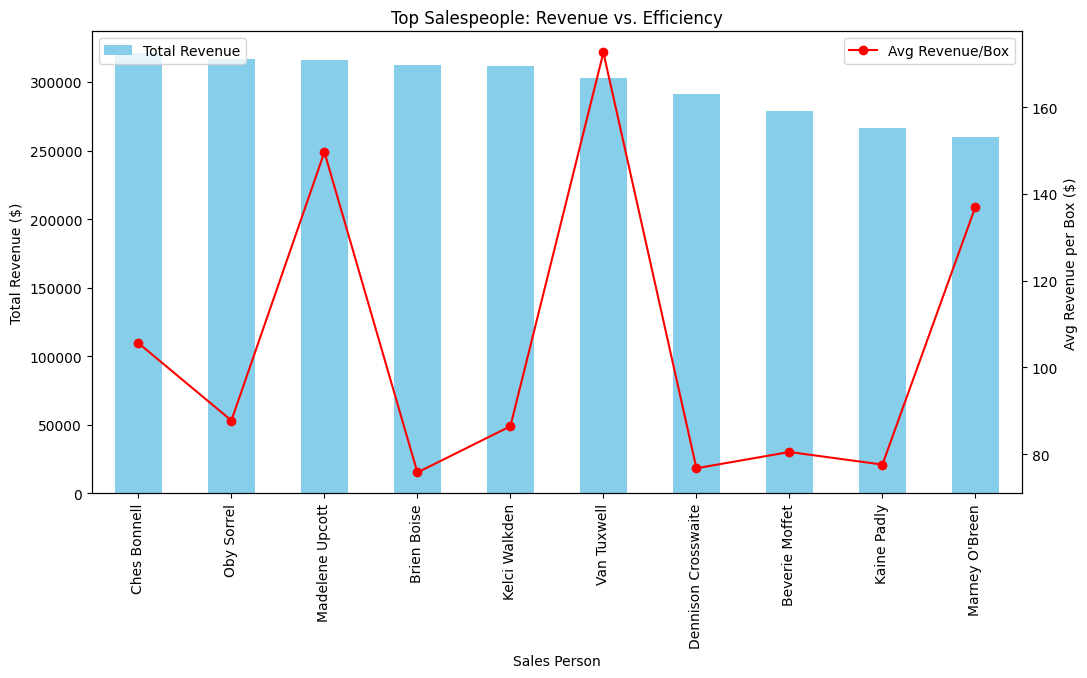

In [ ]:
# Aggregate salesperson data
salesperson_stats = df_clean.groupby('Sales Person').agg(
    Total_Revenue=('Amount', 'sum'),
    Avg_Revenue_per_Box=('Revenue per Box', 'mean')
).nlargest(10, 'Total_Revenue')

# Bar plot
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

salesperson_stats['Total_Revenue'].plot(kind='bar', color='skyblue', ax=ax1, label='Total Revenue')
salesperson_stats['Avg_Revenue_per_Box'].plot(kind='line', marker='o', color='red', ax=ax2, label='Avg Revenue/Box')

ax1.set_ylabel('Total Revenue ($)')
ax2.set_ylabel('Avg Revenue per Box ($)')
plt.title('Top Salespeople: Revenue vs. Efficiency')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

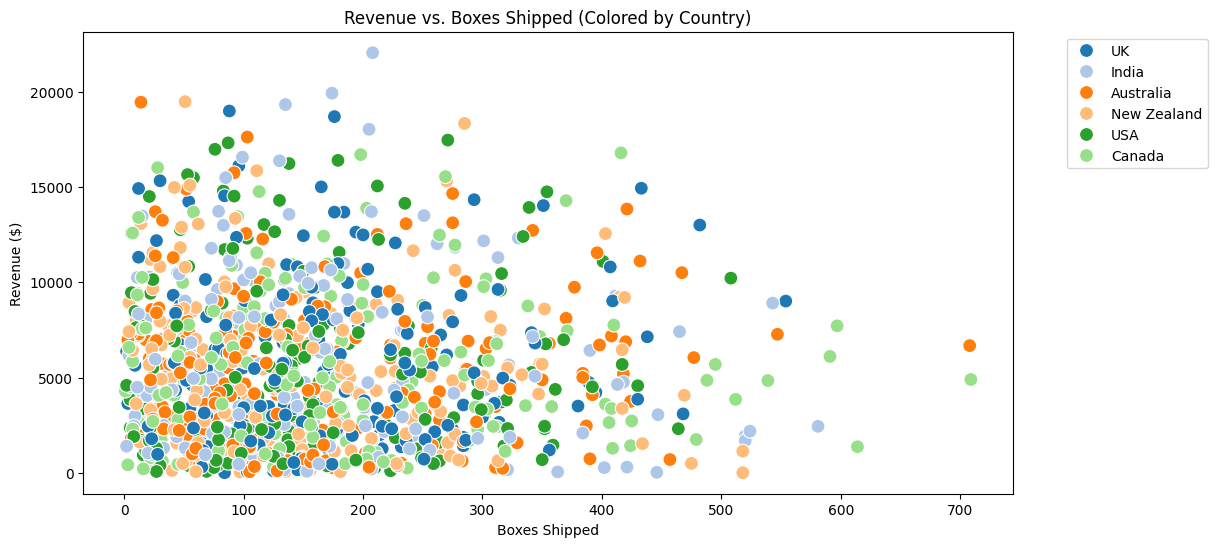

In [ ]:
# Scatter plot by country
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_clean,
    x='Boxes Shipped',
    y='Amount',
    hue='Country',
    palette='tab20',
    s=100
)
plt.title('Revenue vs. Boxes Shipped (Colored by Country)')
plt.xlabel('Boxes Shipped')
plt.ylabel('Revenue ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

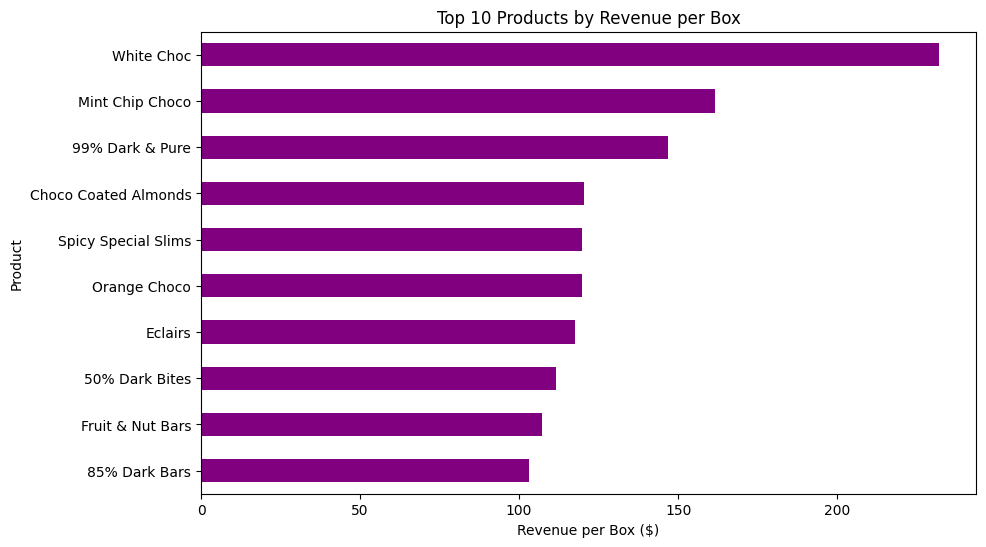

In [ ]:
# Calculate average revenue per box by product
product_value = df_clean.groupby('Product')['Revenue per Box'].mean().nlargest(10)

# Horizontal bar plot
plt.figure(figsize=(10, 6))
product_value.sort_values().plot(kind='barh', color='purple')
plt.title('Top 10 Products by Revenue per Box')
plt.xlabel('Revenue per Box ($)')
plt.ylabel('Product')
plt.show()

<ipython-input-10-4a145f6f01dc>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='Country', y='Amount', palette='Set2')


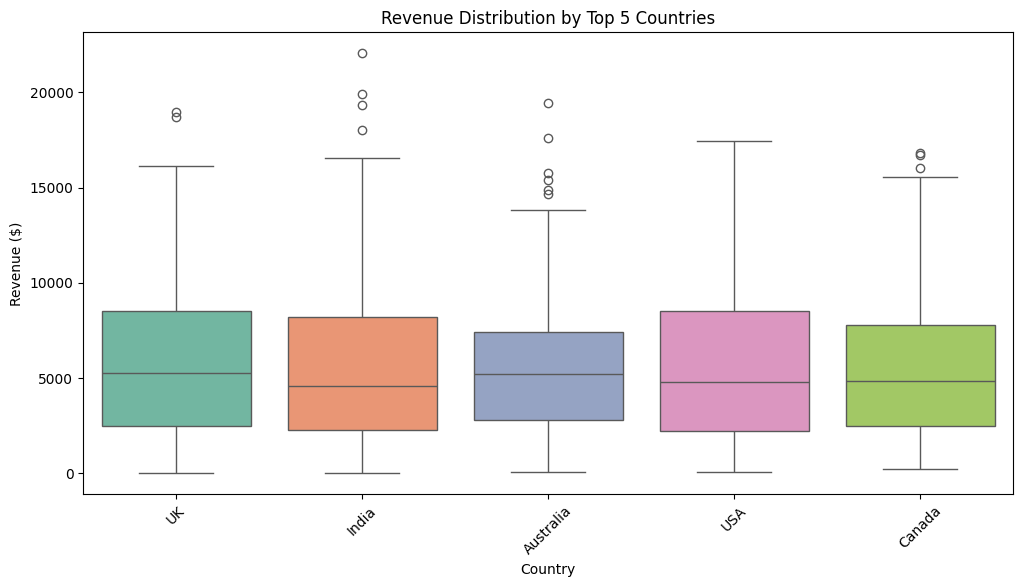

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Processed_Chocolate_Sales.csv')

# Filter top 5 countries by total revenue
top_countries = df.groupby('Country')['Amount'].sum().nlargest(5).index.tolist()
filtered_df = df[df['Country'].isin(top_countries)]

# Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_df, x='Country', y='Amount', palette='Set2')
plt.title('Revenue Distribution by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()